### Week 9 Matplotlib Practice Problems (continued)

### Problem 1 Matplotlib practice

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline, BSpline, make_interp_spline, interp1d

# Create sample data
x = np.array([0, 1, 2, 3, 4, 5])
y = np.array([0, 2, 1, 3, 7, 4])

# Create a finer x-axis for interpolation
x_new = np.linspace(0, 5, 200)

# Linear Interpolation (using interp1d for comparison, but note it's legacy)
f_linear = interp1d(x, y, kind='linear')
y_linear = f_linear(x_new)

# Cubic Spline (using CubicSpline)
cs = CubicSpline(x, y)
y_cubic = cs(x_new)

# B-Spline
bs = make_interp_spline(x, y, k=3)  # k=3 for cubic B-spline
y_bspline = bs(x_new)

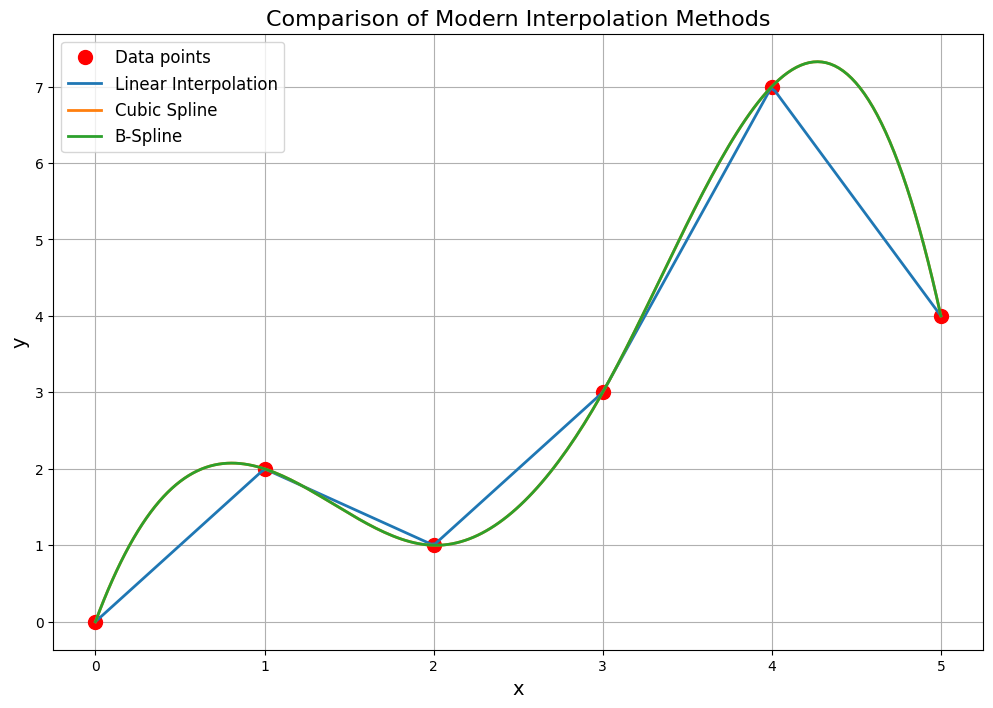

In [42]:
# Create a plot with 

# 1) Linear Interpolation, Cubic Spline,  B-Spline
# 1) A title named Comparison of Modern Interpolation Methods, with fontsize=16
# 2) x-axis: x
# 3) y-axis: y
# 4) Add legend with fontsize=12
# 5) Add grid
plt.figure(figsize=(12, 8))
plt.plot(x, y, 'ro', label='Data points', markersize=10)
plt.plot(x_new, y_linear, label='Linear Interpolation', linewidth=2)
plt.plot(x_new, y_cubic, label='Cubic Spline', linewidth=2)
plt.plot(x_new, y_bspline, label='B-Spline', linewidth=2)
plt.title('Comparison of Modern Interpolation Methods', fontsize=16)
plt.xlabel('x', fontsize=14)
plt.ylabel('y', fontsize=14)
plt.legend(fontsize=12)
plt.grid()
plt.show()

## Additional Practice

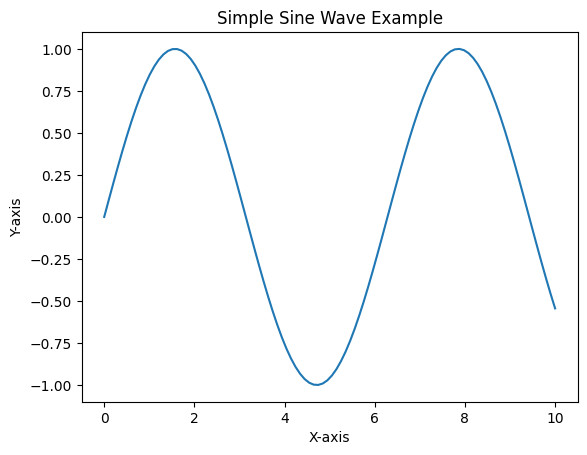

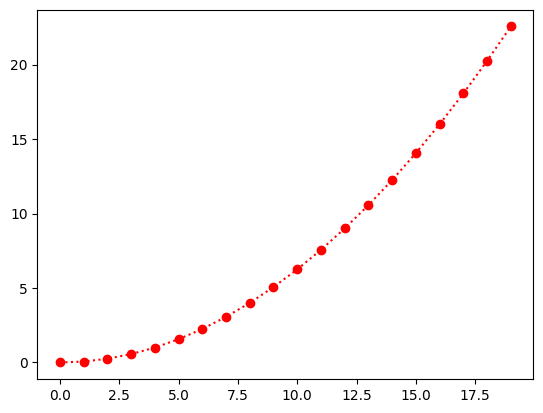

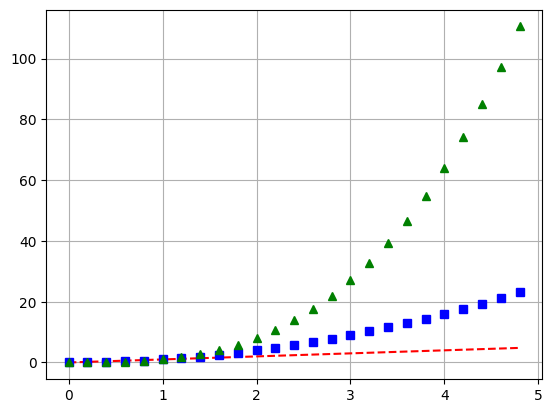

In [ ]:
## Basic plotting: matplotlib.pyplot.plot 
x = np.linspace(0, 10, 100); y = np.sin(x)
plt.plot(x, y) 
plt.title("Simple Sine Wave Example")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.show()

# customizing plots 
x = np.arange(0, 5, 0.25, dtype = float)
_ = plt.plot(x**2, ':ro') #line type, line color, marker type 
# _ = plt.plot(x**2, color='red', linestyle=":", marker='o') 

# multiple lines in a single plot 
plt.figure()
t = np.arange(0., 5., 0.2)
plt.grid() #apply grid to figure
plt.plot(t, t, 'r--')
plt.plot(t, t**2, 'bs')
plt.plot(t, t**3, 'g^')
_ = plt.show()

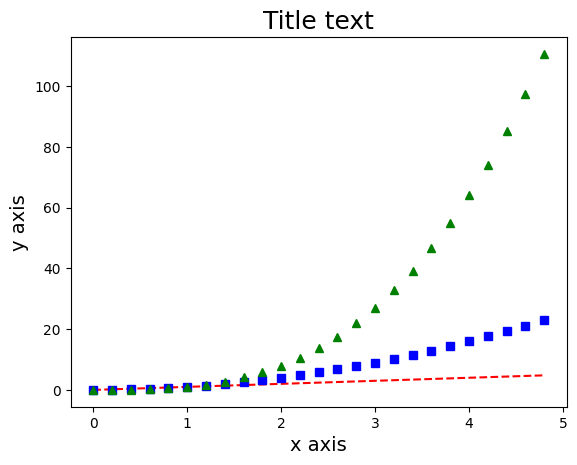

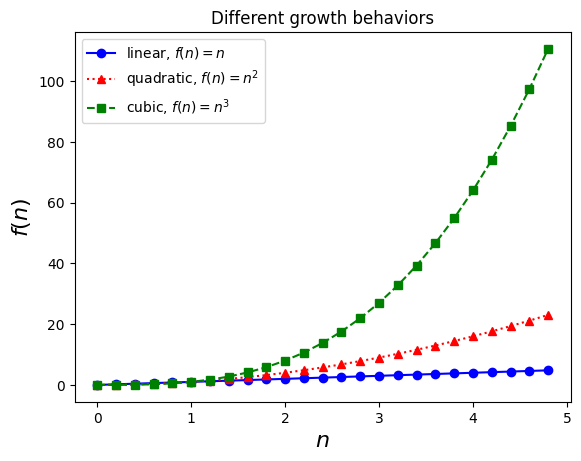

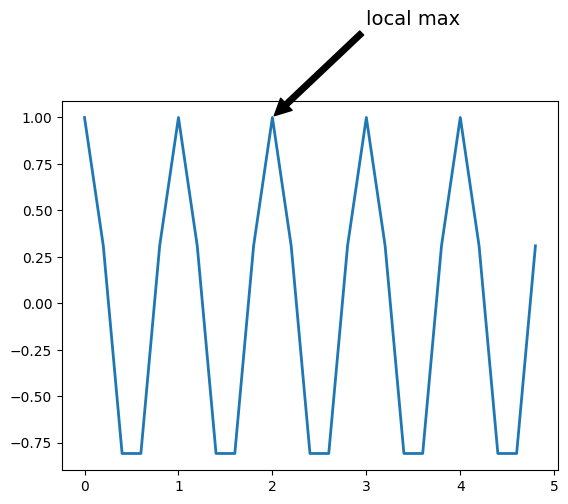

In [ ]:
# Titles and axis labels 
t = np.arange(0., 5., 0.2)
plt.title("Title text", fontsize = 18)
plt.xlabel('x axis', fontsize = 14)
plt.ylabel('y axis', fontsize = 14)
_ = plt.plot(t, t, 'r--', t, t**2, 'bs', t, t**3, 'g^')

# Legends 
plt.figure()
plt.xlabel("$n$", fontsize = 16)
plt.ylabel("$f(n)$", fontsize = 16)
plt.title("Different growth behaviors")
plt.plot(t, t, '-ob', label = 'linear, $f(n) = n$')
plt.plot(t, t**2, ':^r', label='quadratic, $f(n)=n^2$')
plt.plot(t, t**3, '--sg', label='cubic, $f(n)=n^3$')  # fixed: ** for power
_ = plt.legend(loc='best')

# Annotating figures 
    # specify text coords and coords of arrowhead using coords of plot itself 
t = np.arange(0., 5., 0.2)
s = np.cos(2*np.pi*t)
plt.figure()
plt.plot(t, s, lw=2)
_ = plt.annotate('local max', xy = (2,1), xytext = (3, 1.5), 
                 fontsize = 14, 
                 arrowprops = dict(facecolor='black', shrink=0.02))

C:\Users\Bryant Willoughby\AppData\Local\Temp\ipykernel_25520\3155543474.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  _ = plt.boxplot(draws, labels = list('JFMAMJJASOND'))


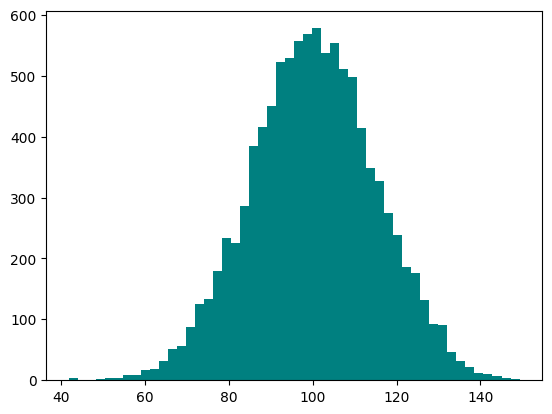

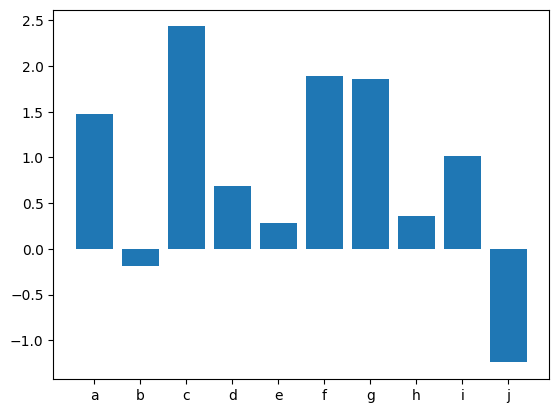

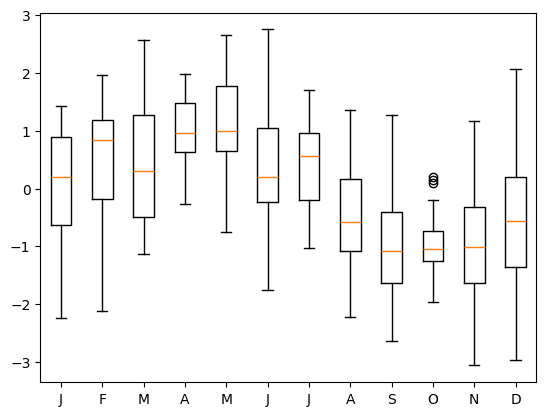

In [32]:
# Plotting histograms: pytplot.hist() 
mu, sigma = (100, 15)
x = np.random.normal(mu, sigma, 10000)
(n, bins, patches) = plt.hist(x, 50, density = False, facecolor = 'teal')
n

# Bar plots 
import string 
plt.figure()
t = np.arange(10)
np.random.seed(1234)
s = np.random.normal(1, 1, 10)
mylabels = list(string.ascii_lowercase[0:len(t)])
_ = plt.bar(t, s, tick_label = mylabels, align = 'center')

# Box & whisker plots 
K = 12; n = 25
draws = np.zeros((n, K))
plt.figure()
for k in range(K): 
    mu = np.sin(2*np.pi*k/K)
    np.random.seed(1234 + k)
    draws[:,k] = np.random.normal(mu, 1, n)
_ = plt.boxplot(draws, labels = list('JFMAMJJASOND'))

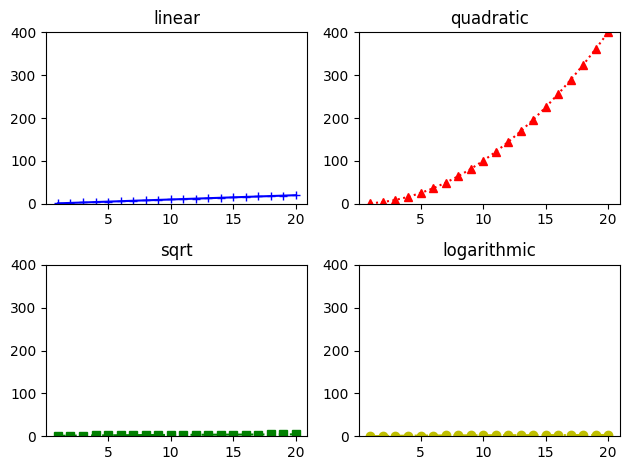

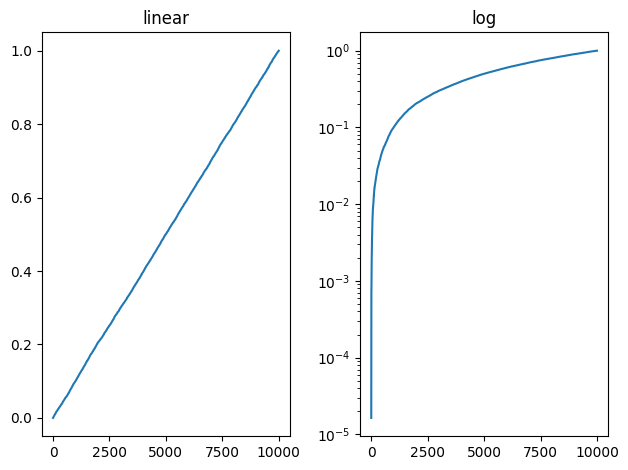

In [39]:
# Subplots 
    # subplot(nrows, ncols, plot_number)
t = np.arange(20) + 1; ymax = np.max(t**2)
plt.subplot(221)
plt.plot(t, t, '-+b')
plt.title('linear')
plt.subplot(222)
plt.title('quadratic')
plt.plot(t, t**2, ':^r')
plt.subplot(223)
plt.title('sqrt')
plt.plot(t, np.sqrt(t), '--sg')
plt.subplot(224)
plt.title('logarithmic')
plt.plot(t, np.log(t), '-.oy')
# _ is a throwaway variable
    # suppress printed return values as especially seen in notebooks
_ = plt.tight_layout()  # adjust spacing to prevent overlap
# specifying axis ranges 
    # plt.ylim([lower, upper]); plt.xlim([lower, upper])
for subplt in range(221, 225): 
    plt.subplot(subplt)
    plt.ylim([0, ymax])
_ = plt.tight_layout()

# Nonlinear axis 
    # scale with plt.xcale and plt.yscale 
    # built-in scales: 'linear', 'log', 'symlog', 'logit'
y = np.random.uniform(0, 1, 10000); y.sort() 
x = np.arange(len(y))
plt.figure()
plt.subplot(121)
plt.plot(x, y)
plt.yscale('linear'); plt.title('linear')
plt.subplot(122)
plt.plot(x, y)
plt.yscale('log'); plt.title('log')
_ = plt.tight_layout()



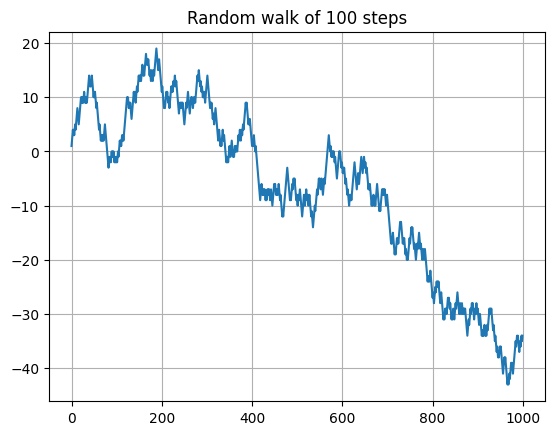

In [40]:
# Saving images 
np.random.seed(0)
random_signs = np.sign(np.random.rand(1000)-0.5)
plt.grid(True)
plt.title('Random walk of 100 steps')
_ = plt.plot(np.cumsum(random_signs))
plt.savefig('random_walk.png')